In [47]:
import pandas as pd
import numpy as np
import seaborn as sns


In [48]:
import matplotlib.pyplot as plt
plt.style.use("ggplot")
plt.rcParams['figure.figsize'] = (12, 8)

In [49]:
df = pd.read_csv('Advertising.csv')

df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


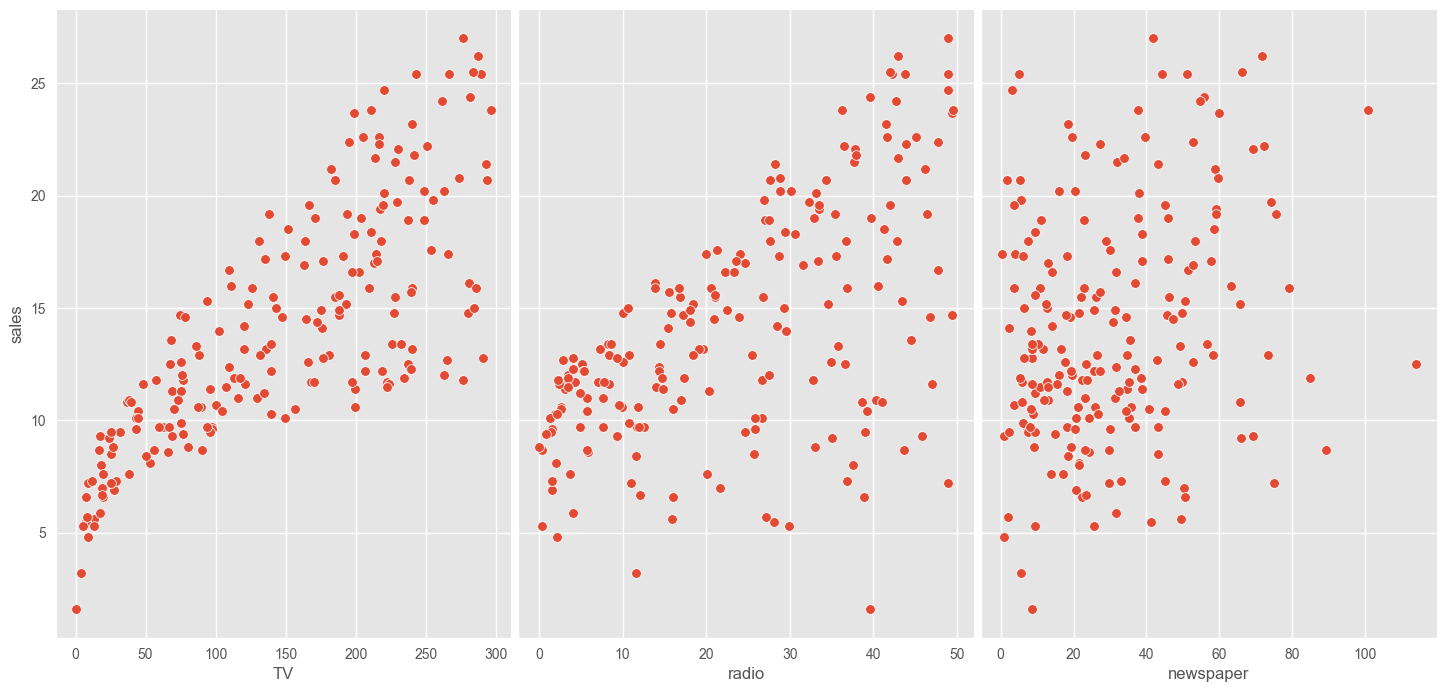

In [51]:
sns.pairplot(df, x_vars=['TV', 'radio', 'newspaper'], y_vars='sales',
             height=7, aspect=0.7)

In [52]:
from sklearn.linear_model import LinearRegression

X = df[['TV', 'radio', 'newspaper']]
y = df.sales

lm1 = LinearRegression()
lm1.fit(X, y)

print(f'Value of Intercept : {lm1.intercept_}')
print(f'Value of coeff : {lm1.coef_}')

Value of Intercept : 2.938889369459412
Value of coeff : [ 0.04576465  0.18853002 -0.00103749]


In [53]:
list(zip(['TV', 'radio', 'newspaper'], lm1.coef_))

[('TV', 0.0457646454553976),
 ('radio', 0.18853001691820445),
 ('newspaper', -0.0010374930424763285)]

In [54]:
from sklearn.metrics import r2_score

lm2 = LinearRegression().fit(X[['TV', 'radio']], y)
lm2_preds = lm2.predict(X[['TV', 'radio']])

print('R^2 : ', r2_score(y, lm2_preds))

R^2 :  0.8971942610828957


In [55]:
lm3 = LinearRegression().fit(X[['TV', 'radio', 'newspaper']], y)
lm3_preds = lm3.predict(X[['TV', 'radio', 'newspaper']])

print('R^2 : ', r2_score(y, lm3_preds))

R^2 :  0.8972106381789522


In [56]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X = df[['TV', 'radio', 'newspaper']]
y = df.sales

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

lm4 = LinearRegression().fit(X_train, y_train)
lm4_preds = lm4.predict(X_test)

print('RMSE : ', np.sqrt(mean_squared_error(y_test, lm4_preds)))
print('R^2 : ', r2_score(y_test, lm4_preds))

RMSE :  1.404651423032896
R^2 :  0.9156213613792231


In [57]:
X = df[['TV', 'radio']]
y = df.sales

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

lm5 = LinearRegression().fit(X_train, y_train)
lm5_preds = lm5.predict(X_test)

print('RMSE : ', np.sqrt(mean_squared_error(y_test, lm5_preds)))
print('R^2 : ', r2_score(y_test, lm5_preds))

RMSE :  1.3879034699382888
R^2 :  0.9176214942248907


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


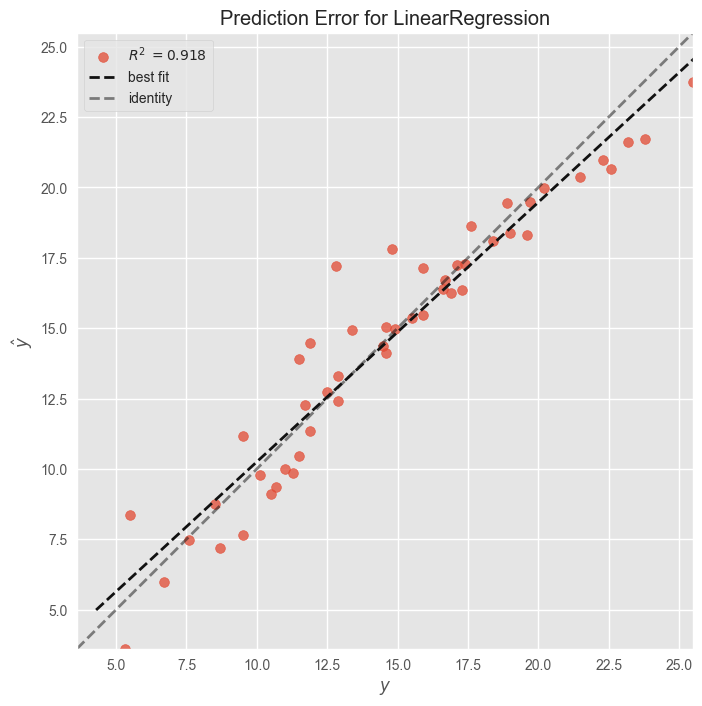

<Axes: title={'center': 'Prediction Error for LinearRegression'}, xlabel='$y$', ylabel='$\\hat{y}$'>

In [58]:
from yellowbrick.regressor import PredictionError, ResidualsPlot

visualizer = PredictionError(lm5).fit(X_train, y_train)
visualizer.score(X_test, y_test)
visualizer.poof()

In [59]:
df['interaction'] = df['TV'] * df['radio']

X = df[['TV', 'radio', 'interaction']]
y = df.sales

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

lm6 = LinearRegression().fit(X_train, y_train)
lm6_preds = lm6.predict(X_test)

print('RMSE : ', np.sqrt(mean_squared_error(y_test, lm6_preds)))
print('R^2 : ', r2_score(y_test, lm6_preds))

RMSE :  0.7011871137164328
R^2 :  0.978973681468126


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


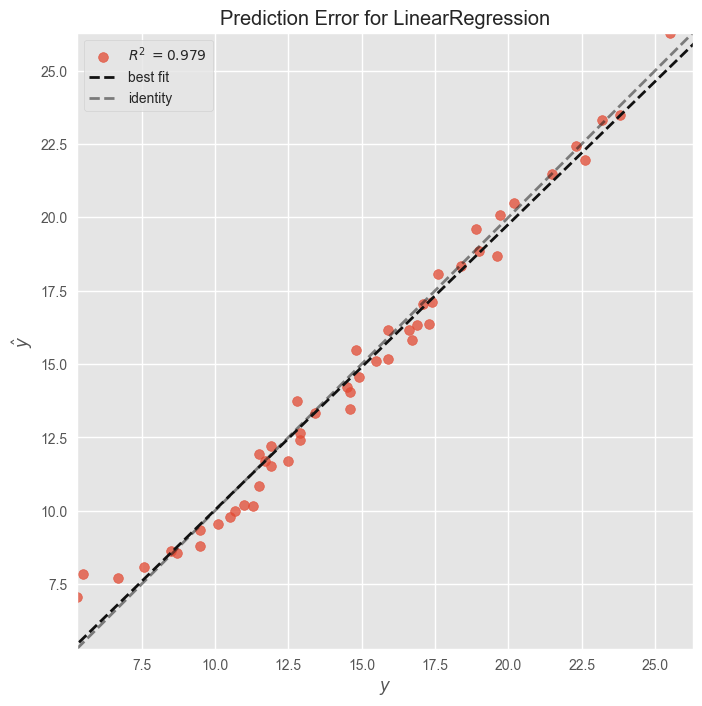

<Axes: title={'center': 'Prediction Error for LinearRegression'}, xlabel='$y$', ylabel='$\\hat{y}$'>

In [60]:
from yellowbrick.regressor import PredictionError, ResidualsPlot

visualizer = PredictionError(lm6).fit(X_train, y_train)
visualizer.score(X_test, y_test)
visualizer.poof()